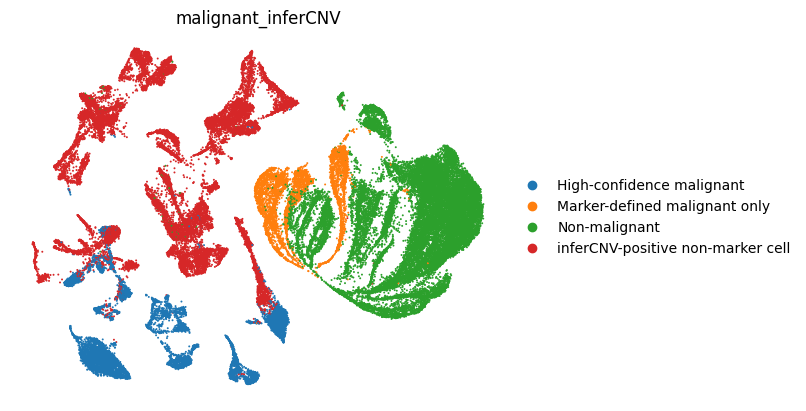

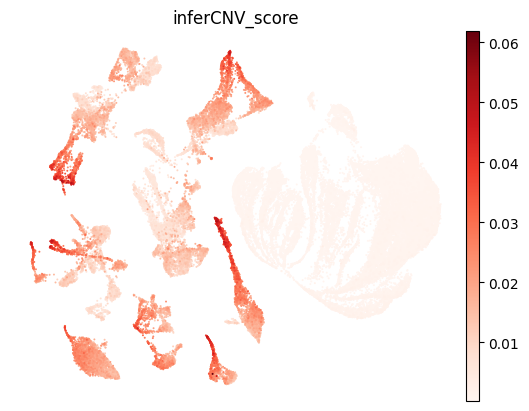

In [1]:
import scanpy as sc
import pandas as pd

OUTDIR = "/mnt/zhangzheng_group/liuz-52/Test_R/01_Figure1_python"

adata = sc.read_h5ad(f"{OUTDIR}/Step10_adata_all_final_celltype.h5ad")

meta = pd.read_csv(
    f"{OUTDIR}/inferCNV_results/Figure1_marker_malignant_inferCNV_intersection_metadata.csv",
    index_col=0
)

adata.obs["inferCNV_score"] = meta.loc[adata.obs_names, "inferCNV_score"]
adata.obs["inferCNV_positive"] = meta.loc[adata.obs_names, "inferCNV_positive"]
adata.obs["malignant_inferCNV"] = meta.loc[adata.obs_names, "malignant_inferCNV"]

sc.pl.umap(
    adata,
    color="malignant_inferCNV",
    frameon=False,
    size=8,
    save="_malignant_inferCNV_intersection.pdf"
)

sc.pl.umap(
    adata,
    color="inferCNV_score",
    frameon=False,
    size=8,
    cmap="Reds",
    save="_inferCNV_score.pdf"
)

adata.write_h5ad(f"{OUTDIR}/Step11_adata_with_inferCNV_malignant.h5ad")